Klik tombol di bawah ini untuk memilih dan mengunggah file CSV Anda:


Saving Kelas E_Teen Mental Health.csv to Kelas E_Teen Mental Health (9).csv

[Berhasil] File 'Kelas E_Teen Mental Health (9).csv' berhasil dibaca!
Kolom yang ada di dalam file Anda saat ini adalah:
['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']

[Peringatan] Kolom 'Human_development' atau 'Maternal_mortality' tidak ditemukan di file ini.
Sistem otomatis beralih menggunakan data yang tersedia (Tingkat Stres berdasarkan Interaksi Sosial)...


/tmp/ipykernel_762/110851275.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_x, y=target_y, data=std_dev, palette='Set2', edgecolor='black')


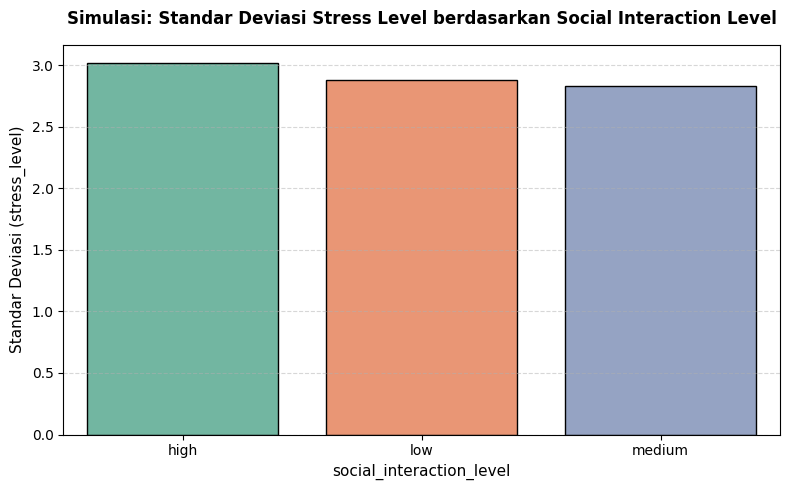

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("Klik tombol di bawah ini untuk memilih dan mengunggah file CSV Anda:")
uploaded = files.upload()


nama_file_terupload = list(uploaded.keys())[0]
df = pd.read_csv(nama_file_terupload)

print(f"\n[Berhasil] File '{nama_file_terupload}' berhasil dibaca!")
print("Kolom yang ada di dalam file Anda saat ini adalah:")
print(df.columns.tolist())


target_x = 'Human_development'
target_y = 'Maternal_mortality'


if target_x in df.columns and target_y in df.columns:

    std_dev = df.groupby(target_x)[target_y].std().reset_index()
    judul_grafik = f'Standar Deviasi {target_y} berdasarkan {target_x}'
else:

    print(f"\n[Peringatan] Kolom '{target_x}' atau '{target_y}' tidak ditemukan di file ini.")
    print("Sistem otomatis beralih menggunakan data yang tersedia (Tingkat Stres berdasarkan Interaksi Sosial)...")

    target_x = 'social_interaction_level'
    target_y = 'stress_level'
    std_dev = df.groupby(target_x)[target_y].std().reset_index()
    judul_grafik = 'Simulasi: Standar Deviasi Stress Level berdasarkan Social Interaction Level'


plt.figure(figsize=(8, 5))
sns.barplot(x=target_x, y=target_y, data=std_dev, palette='Set2', edgecolor='black')


plt.title(judul_grafik, fontsize=12, fontweight='bold', pad=15)
plt.xlabel(target_x, fontsize=11)
plt.ylabel(f'Standar Deviasi ({target_y})', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

Saving Kelas E_Teen Mental Health.csv to Kelas E_Teen Mental Health (8).csv
Total remaja yang memenuhi kriteria: 42
 age gender platform_usage  academic_performance
  14   male           Both                  3.90
  13   male           Both                  3.99
  15   male           Both                  3.89
  17 female           Both                  4.00
  14   male           Both                  3.87
  15   male           Both                  3.81
  17 female           Both                  3.82
  19   male           Both                  3.99
  13 female           Both                  3.90
  16 female           Both                  3.82
  17   male           Both                  3.90
  13   male           Both                  3.82
  18 female           Both                  3.86
  17   male           Both                  3.95
  14   male           Both                  3.88
  13   male           Both                  3.98
  19 female           Both                  3.88
  

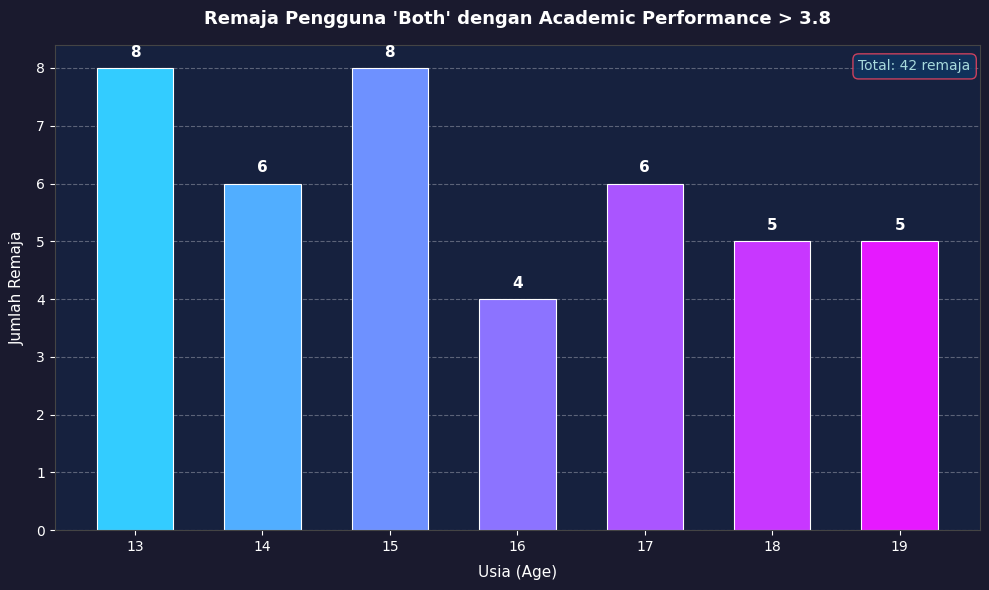

Chart berhasil disimpan: barchart_both_academic.png


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from google.colab import files


uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)


df_both = df[(df['platform_usage'] == 'Both') & (df['academic_performance'] > 3.8)]

print(f"Total remaja yang memenuhi kriteria: {len(df_both)}")
print(df_both[['age', 'gender', 'platform_usage', 'academic_performance']].to_string(index=False))


count_by_age = df_both.groupby('age').size().reset_index(name='jumlah')


fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

colors = plt.cm.cool(np.linspace(0.2, 0.9, len(count_by_age)))

bars = ax.bar(count_by_age['age'].astype(str),
              count_by_age['jumlah'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.6)


for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6), textcoords='offset points',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='white')


ax.set_title("Remaja Pengguna 'Both' dengan Academic Performance > 3.8",
             fontsize=13, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Usia (Age)', fontsize=11, color='white', labelpad=8)
ax.set_ylabel('Jumlah Remaja', fontsize=11, color='white', labelpad=8)
ax.tick_params(colors='white', labelsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

for spine in ax.spines.values():
    spine.set_edgecolor('#444')


ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='white')
ax.set_axisbelow(True)


ax.text(0.99, 0.97, f'Total: {len(df_both)} remaja',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='#a8dadc',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#0f3460',
                  edgecolor='#e94560', alpha=0.85))

plt.tight_layout()
plt.savefig('barchart_both_academic.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Chart berhasil disimpan: barchart_both_academic.png")

Upload file CSV dataset...


Saving Kelas E_Teen Mental Health.csv to Kelas E_Teen Mental Health (3).csv
Dataset berhasil dimuat: 1200 baris, 13 kolom

 Statistik Deskriptif:
       screen_time_before_sleep  sleep_hours
count                   1200.00      1200.00
mean                       1.74         6.45
std                        0.72         1.44
min                        0.50         4.00
25%                        1.10         5.20
50%                        1.80         6.50
75%                        2.40         7.60
max                        3.00         9.00

 Missing Values:
screen_time_before_sleep    0
sleep_hours                 0
dtype: int64

 Hasil Analisis Korelasi:
  Pearson  r  = 0.0102  (p = 0.7232)
  Spearman ρ  = 0.0099  (p = 0.7325)
  R²          = 0.0001
  Persamaan   : sleep_hours = 0.0206 × screen_time + 6.4136

 Interpretasi: Korelasi positif sangat lemah / tidak ada (r = 0.0102)


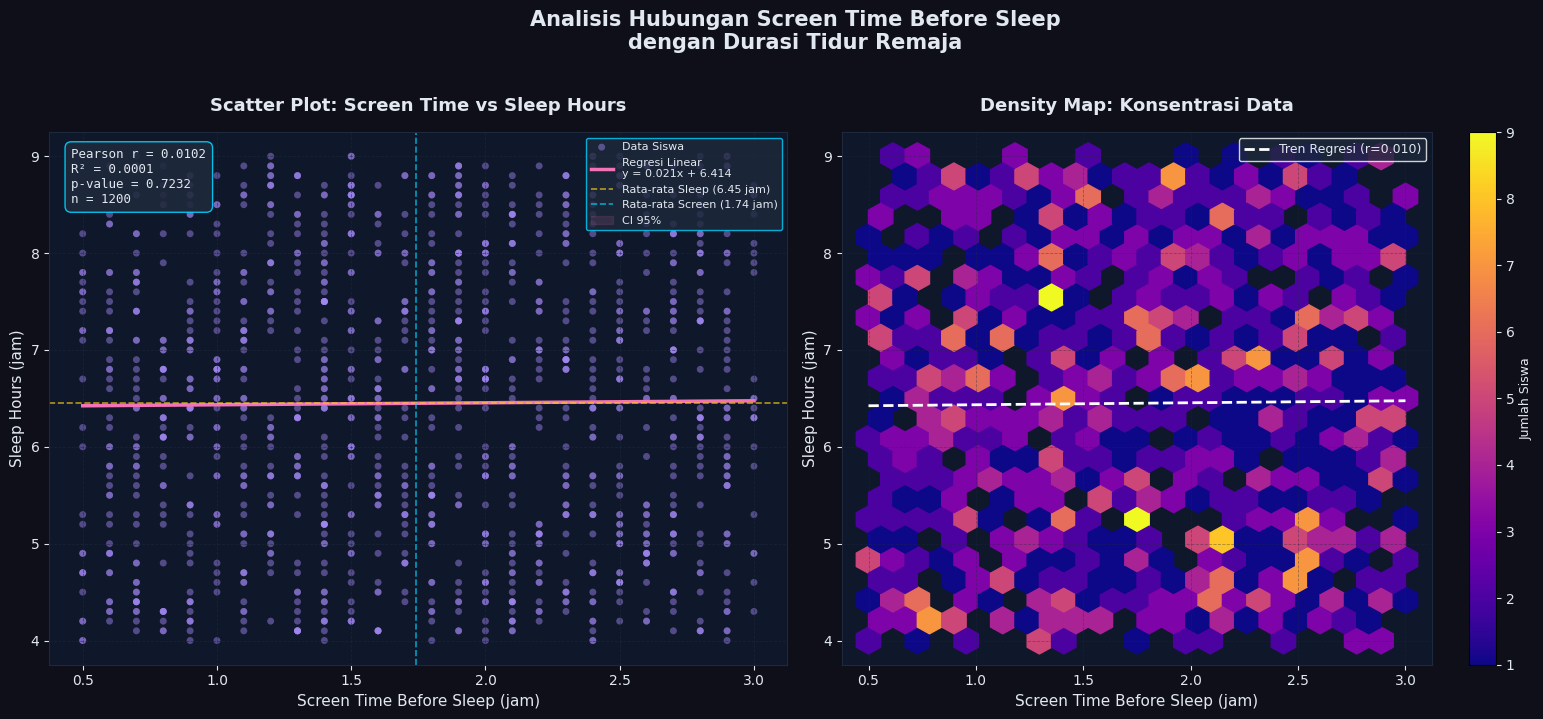


 Plot tersimpan sebagai 'scatter_screen_sleep.png'

  RINGKASAN TEMUAN
  Total data siswa       : 1200
  Rata-rata screen time  : 1.74 jam (±0.72)
  Rata-rata sleep hours  : 6.45 jam (±1.44)
  Korelasi Pearson (r)   : 0.0102
  Korelasi Spearman (ρ)  : 0.0099
  R² (variansi dijelaskan): 0.01%
  Signifikansi (p<0.05)  : TIDAK SIGNIFIKAN (p=0.7232)

 Kesimpulan:
   Terdapat korelasi korelasi positif sangat lemah / tidak ada (r = 0.0102).
   Screen time sebelum tidur hanya menjelaskan 0.01%
   variasi dalam durasi tidur siswa.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from google.colab import files


print("Upload file CSV dataset...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")


print("\n Statistik Deskriptif:")
print(df[['screen_time_before_sleep', 'sleep_hours']].describe().round(2))

print("\n Missing Values:")
print(df[['screen_time_before_sleep', 'sleep_hours']].isnull().sum())


x = df['screen_time_before_sleep']
y = df['sleep_hours']

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2

print("\n Hasil Analisis Korelasi:")
print(f"  Pearson  r  = {pearson_r:.4f}  (p = {pearson_p:.4f})")
print(f"  Spearman ρ  = {spearman_r:.4f}  (p = {spearman_p:.4f})")
print(f"  R²          = {r_squared:.4f}")
print(f"  Persamaan   : sleep_hours = {slope:.4f} × screen_time + {intercept:.4f}")


def interpret_correlation(r):
    r_abs = abs(r)
    direction = "positif" if r > 0 else "negatif"
    if r_abs < 0.1:
        strength = "sangat lemah / tidak ada"
    elif r_abs < 0.3:
        strength = "lemah"
    elif r_abs < 0.5:
        strength = "sedang"
    elif r_abs < 0.7:
        strength = "kuat"
    else:
        strength = "sangat kuat"
    return f"Korelasi {direction} {strength} (r = {r:.4f})"

print(f"\n Interpretasi: {interpret_correlation(pearson_r)}")


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f0f1a')

ACCENT   = '#00d4ff'
SCATTER  = '#a78bfa'
LINE_REG = '#f472b6'
LINE_MEAN= '#facc15'
TEXT_CLR = '#e2e8f0'
GRID_CLR = '#1e293b'
BG_AX    = '#0f172a'


ax1 = axes[0]
ax1.set_facecolor(BG_AX)


ax1.scatter(x, y,
            color=SCATTER, alpha=0.45, s=25,
            edgecolors='none', label='Data Siswa')


x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line,
         color=LINE_REG, linewidth=2.5,
         label=f'Regresi Linear\ny = {slope:.3f}x + {intercept:.3f}')


ax1.axhline(y.mean(), color=LINE_MEAN, linewidth=1.2,
            linestyle='--', alpha=0.7, label=f'Rata-rata Sleep ({y.mean():.2f} jam)')
ax1.axvline(x.mean(), color=ACCENT, linewidth=1.2,
            linestyle='--', alpha=0.7, label=f'Rata-rata Screen ({x.mean():.2f} jam)')


n = len(x)
x_sorted = np.sort(x_line)
se_band = std_err * np.sqrt(1/n + (x_line - x.mean())**2 / ((n-1)*x.std()**2))
y_upper = y_line + 1.96 * se_band
y_lower = y_line - 1.96 * se_band
ax1.fill_between(x_line, y_lower, y_upper,
                 color=LINE_REG, alpha=0.12, label='CI 95%')


stats_text = (f"Pearson r = {pearson_r:.4f}\n"
              f"R² = {r_squared:.4f}\n"
              f"p-value = {pearson_p:.4f}\n"
              f"n = {len(df)}")
ax1.text(0.03, 0.97, stats_text,
         transform=ax1.transAxes, fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1e293b',
                   edgecolor=ACCENT, alpha=0.9),
         color=TEXT_CLR, family='monospace')

ax1.set_xlabel('Screen Time Before Sleep (jam)', color=TEXT_CLR, fontsize=11)
ax1.set_ylabel('Sleep Hours (jam)',               color=TEXT_CLR, fontsize=11)
ax1.set_title('Scatter Plot: Screen Time vs Sleep Hours',
              color=TEXT_CLR, fontsize=13, fontweight='bold', pad=15)

ax1.tick_params(colors=TEXT_CLR)
ax1.spines[:].set_color(GRID_CLR)
ax1.grid(color=GRID_CLR, linestyle='--', linewidth=0.6, alpha=0.6)
leg1 = ax1.legend(fontsize=8, loc='upper right',
                  facecolor='#1e293b', edgecolor=ACCENT, labelcolor=TEXT_CLR)


ax2 = axes[1]
ax2.set_facecolor(BG_AX)

hb = ax2.hexbin(x, y, gridsize=22, cmap='plasma', mincnt=1)
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('Jumlah Siswa', color=TEXT_CLR, fontsize=9)
cb.ax.yaxis.set_tick_params(color=TEXT_CLR)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=TEXT_CLR)

ax2.plot(x_line, y_line,
         color='white', linewidth=2, linestyle='--',
         label=f'Tren Regresi (r={pearson_r:.3f})')

ax2.set_xlabel('Screen Time Before Sleep (jam)', color=TEXT_CLR, fontsize=11)
ax2.set_ylabel('Sleep Hours (jam)',               color=TEXT_CLR, fontsize=11)
ax2.set_title('Density Map: Konsentrasi Data',
              color=TEXT_CLR, fontsize=13, fontweight='bold', pad=15)
ax2.tick_params(colors=TEXT_CLR)
ax2.spines[:].set_color(GRID_CLR)
ax2.grid(color=GRID_CLR, linestyle='--', linewidth=0.6, alpha=0.4)
leg2 = ax2.legend(fontsize=9, loc='upper right',
                  facecolor='#1e293b', edgecolor='white', labelcolor=TEXT_CLR)


fig.suptitle('Analisis Hubungan Screen Time Before Sleep\ndengan Durasi Tidur Remaja',
             color=TEXT_CLR, fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('scatter_screen_sleep.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("\n Plot tersimpan sebagai 'scatter_screen_sleep.png'")


print("\n" + "="*55)
print("  RINGKASAN TEMUAN")
print("="*55)
print(f"  Total data siswa       : {len(df)}")
print(f"  Rata-rata screen time  : {x.mean():.2f} jam (±{x.std():.2f})")
print(f"  Rata-rata sleep hours  : {y.mean():.2f} jam (±{y.std():.2f})")
print(f"  Korelasi Pearson (r)   : {pearson_r:.4f}")
print(f"  Korelasi Spearman (ρ)  : {spearman_r:.4f}")
print(f"  R² (variansi dijelaskan): {r_squared*100:.2f}%")
sig = "SIGNIFIKAN" if pearson_p < 0.05 else "TIDAK SIGNIFIKAN"
print(f"  Signifikansi (p<0.05)  : {sig} (p={pearson_p:.4f})")
print("="*55)
print(f"\n Kesimpulan:")
print(f"   Terdapat korelasi {interpret_correlation(pearson_r).lower()}.")
print(f"   Screen time sebelum tidur hanya menjelaskan {r_squared*100:.2f}%")
print(f"   variasi dalam durasi tidur siswa.")

Saving Kelas E_Teen Mental Health.csv to Kelas E_Teen Mental Health (7).csv
 Dataset berhasil dimuat: 1200 baris, 13 kolom
  STATISTIK DESKRIPTIF — physical_activity
  Jumlah Data  : 1200
  Min          : 0.0
  Max          : 2.0
  Mean         : 1.0145
  Median       : 1.0
  Std Dev      : 0.5822
  DETEKSI PENCILAN — Metode Tukey's Fences
  Q1              : 0.5
  Q3              : 1.5
  IQR (Q3-Q1)     : 1.0
  Batas Bawah     : Q1 - 1.5×IQR = -1.0
  Batas Atas      : Q3 + 1.5×IQR = 3.0
---------------------------------------------
  Jumlah Pencilan : 0
 Tidak ditemukan pencilan (outlier)!


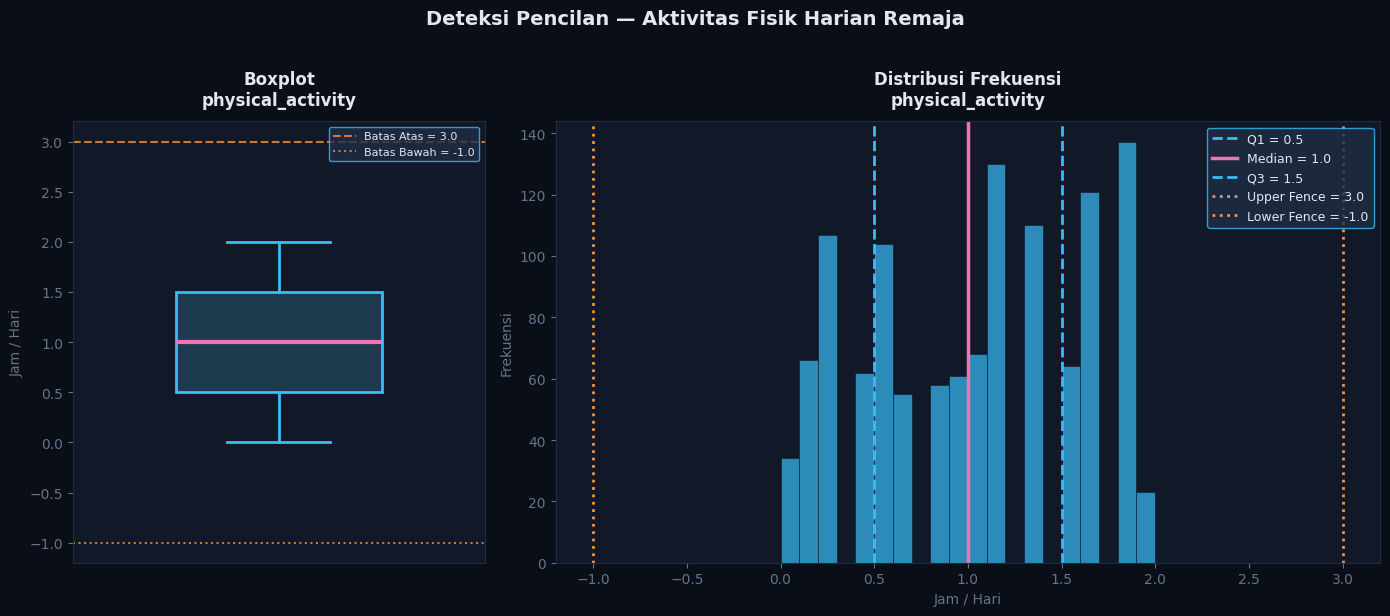

 Grafik tersimpan sebagai boxplot_physical_activity.png
         KESIMPULAN ANALISIS PENCILAN
  Kolom    : physical_activity
  Metode   : Tukey's Fences (1.5 × IQR)
  n data   : 1200

  Q1       = 0.5
  Median   = 1.0
  Q3       = 1.5
  IQR      = 1.0

  Lower Fence = -1.0  (Q1 - 1.5×IQR)
  Upper Fence = 3.0   (Q3 + 1.5×IQR)

   HASIL: Tidak ditemukan pencilan.
     Semua data berada dalam rentang normal.
     [0.0 – 2.0] ⊂ [-1.0 – 3.0]


In [24]:
!pip install matplotlib seaborn pandas -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from google.colab import files

uploaded = files.upload()


import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f" Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

col = 'physical_activity'

print("=" * 45)
print("  STATISTIK DESKRIPTIF — physical_activity")
print("=" * 45)
print(f"  Jumlah Data  : {df[col].count()}")
print(f"  Min          : {df[col].min()}")
print(f"  Max          : {df[col].max()}")
print(f"  Mean         : {df[col].mean():.4f}")
print(f"  Median       : {df[col].median()}")
print(f"  Std Dev      : {df[col].std():.4f}")
print("=" * 45)
col = 'physical_activity'

Q1  = df[col].quantile(0.25)
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

outliers = df[(df[col] < batas_bawah) | (df[col] > batas_atas)]

print("=" * 45)
print("  DETEKSI PENCILAN — Metode Tukey's Fences")
print("=" * 45)
print(f"  Q1              : {Q1}")
print(f"  Q3              : {Q3}")
print(f"  IQR (Q3-Q1)     : {IQR}")
print(f"  Batas Bawah     : Q1 - 1.5×IQR = {batas_bawah}")
print(f"  Batas Atas      : Q3 + 1.5×IQR = {batas_atas}")
print("-" * 45)
print(f"  Jumlah Pencilan : {len(outliers)}")

if len(outliers) == 0:
    print(" Tidak ditemukan pencilan (outlier)!")
else:
    print(f"  Data pencilan ditemukan:")
    print(outliers[[col]])
print("=" * 45)
col = 'physical_activity'

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         gridspec_kw={'width_ratios': [1, 2]})
fig.patch.set_facecolor('#0a0e17')


ax1 = axes[0]
ax1.set_facecolor('#111827')

bp = ax1.boxplot(df[col], vert=True, patch_artist=True,
                 widths=0.5,
                 boxprops=dict(facecolor='#1e3a4f', color='#38bdf8', linewidth=2),
                 medianprops=dict(color='#f472b6', linewidth=3),
                 whiskerprops=dict(color='#38bdf8', linewidth=2),
                 capprops=dict(color='#38bdf8', linewidth=2),
                 flierprops=dict(marker='o', color='#fb923c',
                                 markerfacecolor='#fb923c', markersize=8))


ax1.axhline(batas_atas,  color='#fb923c', linestyle='--',
            linewidth=1.5, alpha=0.8, label=f'Batas Atas = {batas_atas}')
ax1.axhline(batas_bawah, color='#fb923c', linestyle=':',
            linewidth=1.5, alpha=0.8, label=f'Batas Bawah = {batas_bawah}')

ax1.set_title('Boxplot\nphysical_activity',
              color='#e2e8f0', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('Jam / Hari', color='#64748b', fontsize=10)
ax1.set_xticks([])
ax1.tick_params(colors='#64748b')
ax1.spines[['top','right','bottom','left']].set_color('#1e2d45')
ax1.yaxis.label.set_color('#64748b')
for spine in ax1.spines.values():
    spine.set_edgecolor('#1e2d45')
ax1.legend(fontsize=8, facecolor='#1e2d45',
           labelcolor='#e2e8f0', edgecolor='#38bdf8')


ax2 = axes[1]
ax2.set_facecolor('#111827')

ax2.hist(df[col], bins=20, color='#38bdf8', alpha=0.7,
         edgecolor='#0a0e17', linewidth=0.5)
ax2.axvline(Q1,           color='#38bdf8', linestyle='--',
            linewidth=2,  label=f'Q1 = {Q1}')
ax2.axvline(df[col].median(), color='#f472b6', linestyle='-',
            linewidth=2.5, label=f'Median = {df[col].median()}')
ax2.axvline(Q3,           color='#38bdf8', linestyle='--',
            linewidth=2,  label=f'Q3 = {Q3}')
ax2.axvline(batas_atas,   color='#fb923c', linestyle=':',
            linewidth=2,  label=f'Upper Fence = {batas_atas}')
ax2.axvline(batas_bawah,  color='#fb923c', linestyle=':',
            linewidth=2,  label=f'Lower Fence = {batas_bawah}')


if len(outliers) > 0:
    ax2.scatter(outliers[col],
                [5] * len(outliers),
                color='#fb923c', zorder=5,
                s=80, label='Outlier', marker='X')

ax2.set_title('Distribusi Frekuensi\nphysical_activity',
              color='#e2e8f0', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Jam / Hari', color='#64748b', fontsize=10)
ax2.set_ylabel('Frekuensi', color='#64748b', fontsize=10)
ax2.tick_params(colors='#64748b')
for spine in ax2.spines.values():
    spine.set_edgecolor('#1e2d45')
ax2.legend(fontsize=9, facecolor='#1e2d45',
           labelcolor='#e2e8f0', edgecolor='#38bdf8')

plt.suptitle('Deteksi Pencilan — Aktivitas Fisik Harian Remaja',
             color='#e2e8f0', fontsize=14,
             fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('boxplot_physical_activity.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0e17')
plt.show()
print(" Grafik tersimpan sebagai boxplot_physical_activity.png")
print("=" * 50)
print("         KESIMPULAN ANALISIS PENCILAN")
print("=" * 50)
print(f"  Kolom    : physical_activity")
print(f"  Metode   : Tukey's Fences (1.5 × IQR)")
print(f"  n data   : {len(df)}")
print()
print(f"  Q1       = {Q1}")
print(f"  Median   = {df[col].median()}")
print(f"  Q3       = {Q3}")
print(f"  IQR      = {IQR}")
print()
print(f"  Lower Fence = {batas_bawah}  (Q1 - 1.5×IQR)")
print(f"  Upper Fence = {batas_atas}   (Q3 + 1.5×IQR)")
print()

if len(outliers) == 0:
    print("   HASIL: Tidak ditemukan pencilan.")
    print("     Semua data berada dalam rentang normal.")
    print(f"     [{df[col].min()} – {df[col].max()}] ⊂ [{batas_bawah} – {batas_atas}]")
else:
    print(f"    HASIL: Ditemukan {len(outliers)} data pencilan!")
    print(f"     Perlu penanganan lebih lanjut (hapus/imputasi).")
print("=" * 50)

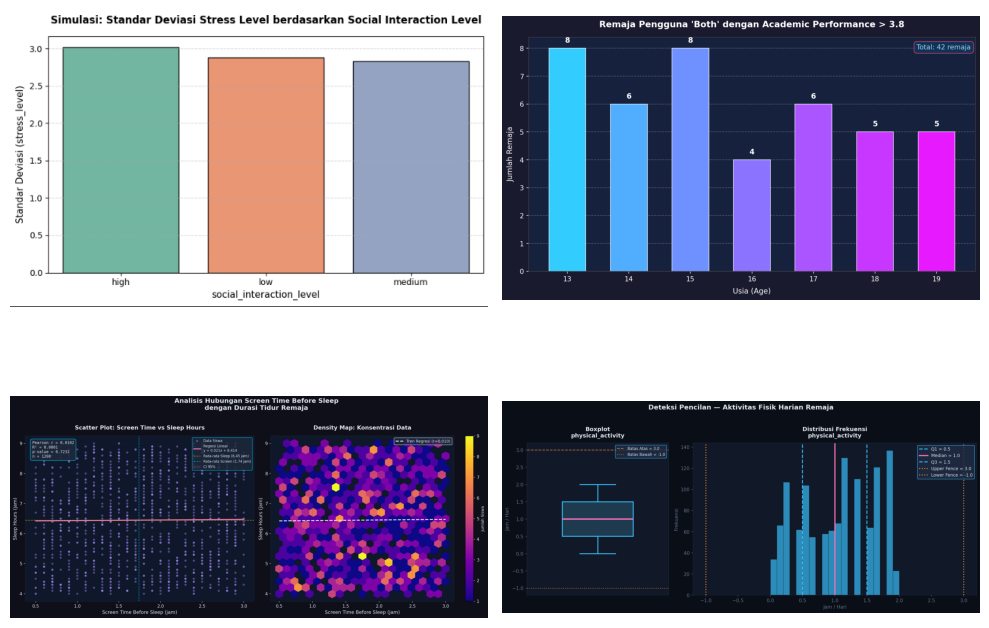

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

img1 = mpimg.imread("barchart_stress_level.png")
img2 = mpimg.imread("barchart_both_academic.png")
img3 = mpimg.imread("scatter_screen_sleep.png")
img4 = mpimg.imread("boxplot_physical_activity.png")

axs[0,0].imshow(img1)
axs[0,0].axis('off')

axs[0,1].imshow(img2)
axs[0,1].axis('off')

axs[1,0].imshow(img3)
axs[1,0].axis('off')

axs[1,1].imshow(img4)
axs[1,1].axis('off')

plt.tight_layout()
plt.show()